 In CIFAR-10, there are 60000, 32x32 color images belonging to 10 classes, with 6000 images from each class. The training dataset contains 50,000 training images and the test dataset contains 10,000 test images.
<br><br>
The dataset images are of color images with a (32 x 32) resolution. All the images in the dataset are of shape (32,32,3) where 3 represents the number of channels i.e R-G-B (Red,Green & Blue).



!!!!!!!!!!
We are going to use only 5 classes of images and 1000 samples each due to model complexity and resource constraint.

## Importing Libraries

In [38]:
pip install visualkeras

Note: you may need to restart the kernel to use updated packages.


In [39]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras.layers import GlobalMaxPooling2D, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers, optimizers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score

import visualkeras
from PIL import ImageFont

import warnings
warnings.filterwarnings('ignore')

print("Tensorflow version:",tf.__version__)
print("Keras version:",keras.__version__)

Tensorflow version: 2.18.0
Keras version: 3.8.0


## Importing & Reading the dataset

 The Keras dataset module already comes with the CIFAR-10 dataset. So,we can directly import it using the ‘keras.datasets’ command.

In [40]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

## Normalizing and One-Hot Encoding

 We have to normalize the data in order to reduce the pixel values. Currently, all the image pixels are in a range from 0–255, and we want the values in the range of 0 and 1. So we can either divide all the pixel values by 255.0 or use the ‘normalize’ command from keras library. As CIFAR-10 has 10 classes, we are using the ‘to_categorical()’ method to one-hot encode the data.

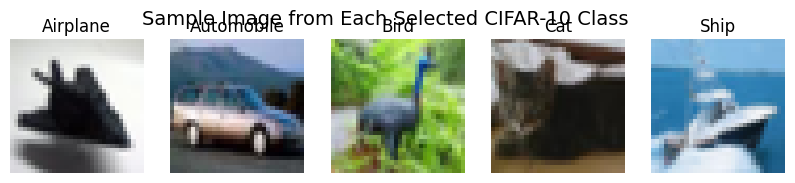

Train set: (10000, 32, 32, 3) (10000, 5)
Test set: (2500, 32, 32, 3) (2500, 5)


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Class mapping
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']
selected_classes = [0, 1, 2, 3, 8]  # Airplane, Automobile, Bird, Cat, Ship

# Load CIFAR-10
(X, y), _ = cifar10.load_data()

# Filter only the selected classes and collect 1000 samples per class
X_filtered, y_filtered = [], []

for cls in selected_classes:
    idx = np.where(y.flatten() == cls)[0][:2500]
    X_filtered.append(X[idx])
    y_filtered.append(y[idx])

# Stack and reshape
X_filtered = np.concatenate(X_filtered)
y_filtered = np.concatenate(y_filtered)

# Normalize images
X_filtered = X_filtered / 255.0

# Remap labels to 0–4
label_map = {old: new for new, old in enumerate(selected_classes)}
y_mapped = np.vectorize(label_map.get)(y_filtered)

# One-hot encode
y_encoded = to_categorical(y_mapped, num_classes=5)

# Split 80/20
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train_en, Y_test_en = train_test_split(
    X_filtered, y_encoded, test_size=0.2, stratify=y_mapped, random_state=42
)

# Show one sample image per class
plt.figure(figsize=(10, 2))
for i, cls in enumerate(selected_classes):
    img = X_filtered[np.where(y_filtered.flatten() == cls)[0][0]]
    plt.subplot(1, 5, i + 1)
    plt.imshow(img, interpolation='nearest')

    plt.title(class_names[cls])
    plt.axis('off')
plt.suptitle("Sample Image from Each Selected CIFAR-10 Class", fontsize=14)
plt.show()

# Final shapes
print("Train set:", X_train.shape, Y_train_en.shape)
print("Test set:", X_test.shape, Y_test_en.shape)


## Building Base Model

Basic CNN model for getting idea of performance

In [42]:

    # Base Model
model0 = Sequential()
model0.add(Conv2D(32,(4,4),input_shape = (32,32,3),activation='relu'))
model0.add(MaxPooling2D(pool_size = (2,2)))
model0.add(Conv2D(32,(4,4),input_shape = (32,32,3),activation='relu'))
model0.add(MaxPooling2D(pool_size = (2,2)))
model0.add(Flatten())
model0.add(Dense(128, activation ='relu'))
model0.add(Dense(5, activation ='softmax'))
model0.compile(loss ='categorical_crossentropy', optimizer ='adam', metrics =['accuracy'])

In [43]:
model0.summary()
history = model0.fit(X_train, Y_train_en, epochs = 30, verbose=1,validation_data=(X_test,Y_test_en))

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 29, 29, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 11, 11, 32)     │        16,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │       102,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,157 (473.27 KB)

 Trainable params: 121,157 (473.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.3967 - loss: 1.3825 - val_accuracy: 0.6208 - val_loss: 0.9601
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6199 - loss: 0.9338 - val_accuracy: 0.6284 - val_loss: 0.9582
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6615 - loss: 0.8491 - val_accuracy: 0.6696 - val_loss: 0.8874
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7007 - loss: 0.7667 - val_accuracy: 0.6988 - val_loss: 0.7844
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7268 - loss: 0.7002 - val_accuracy: 0.6992 - val_loss: 0.7825
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7386 - loss: 0.6679 - val_accuracy: 0.7156 - val_loss: 0.7591
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7730 - loss: 0.5973 - val_accuracy: 0.7036 - val_loss: 0.7845
Epoch 8/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7759 - loss: 0.5835 - val_accuracy: 0

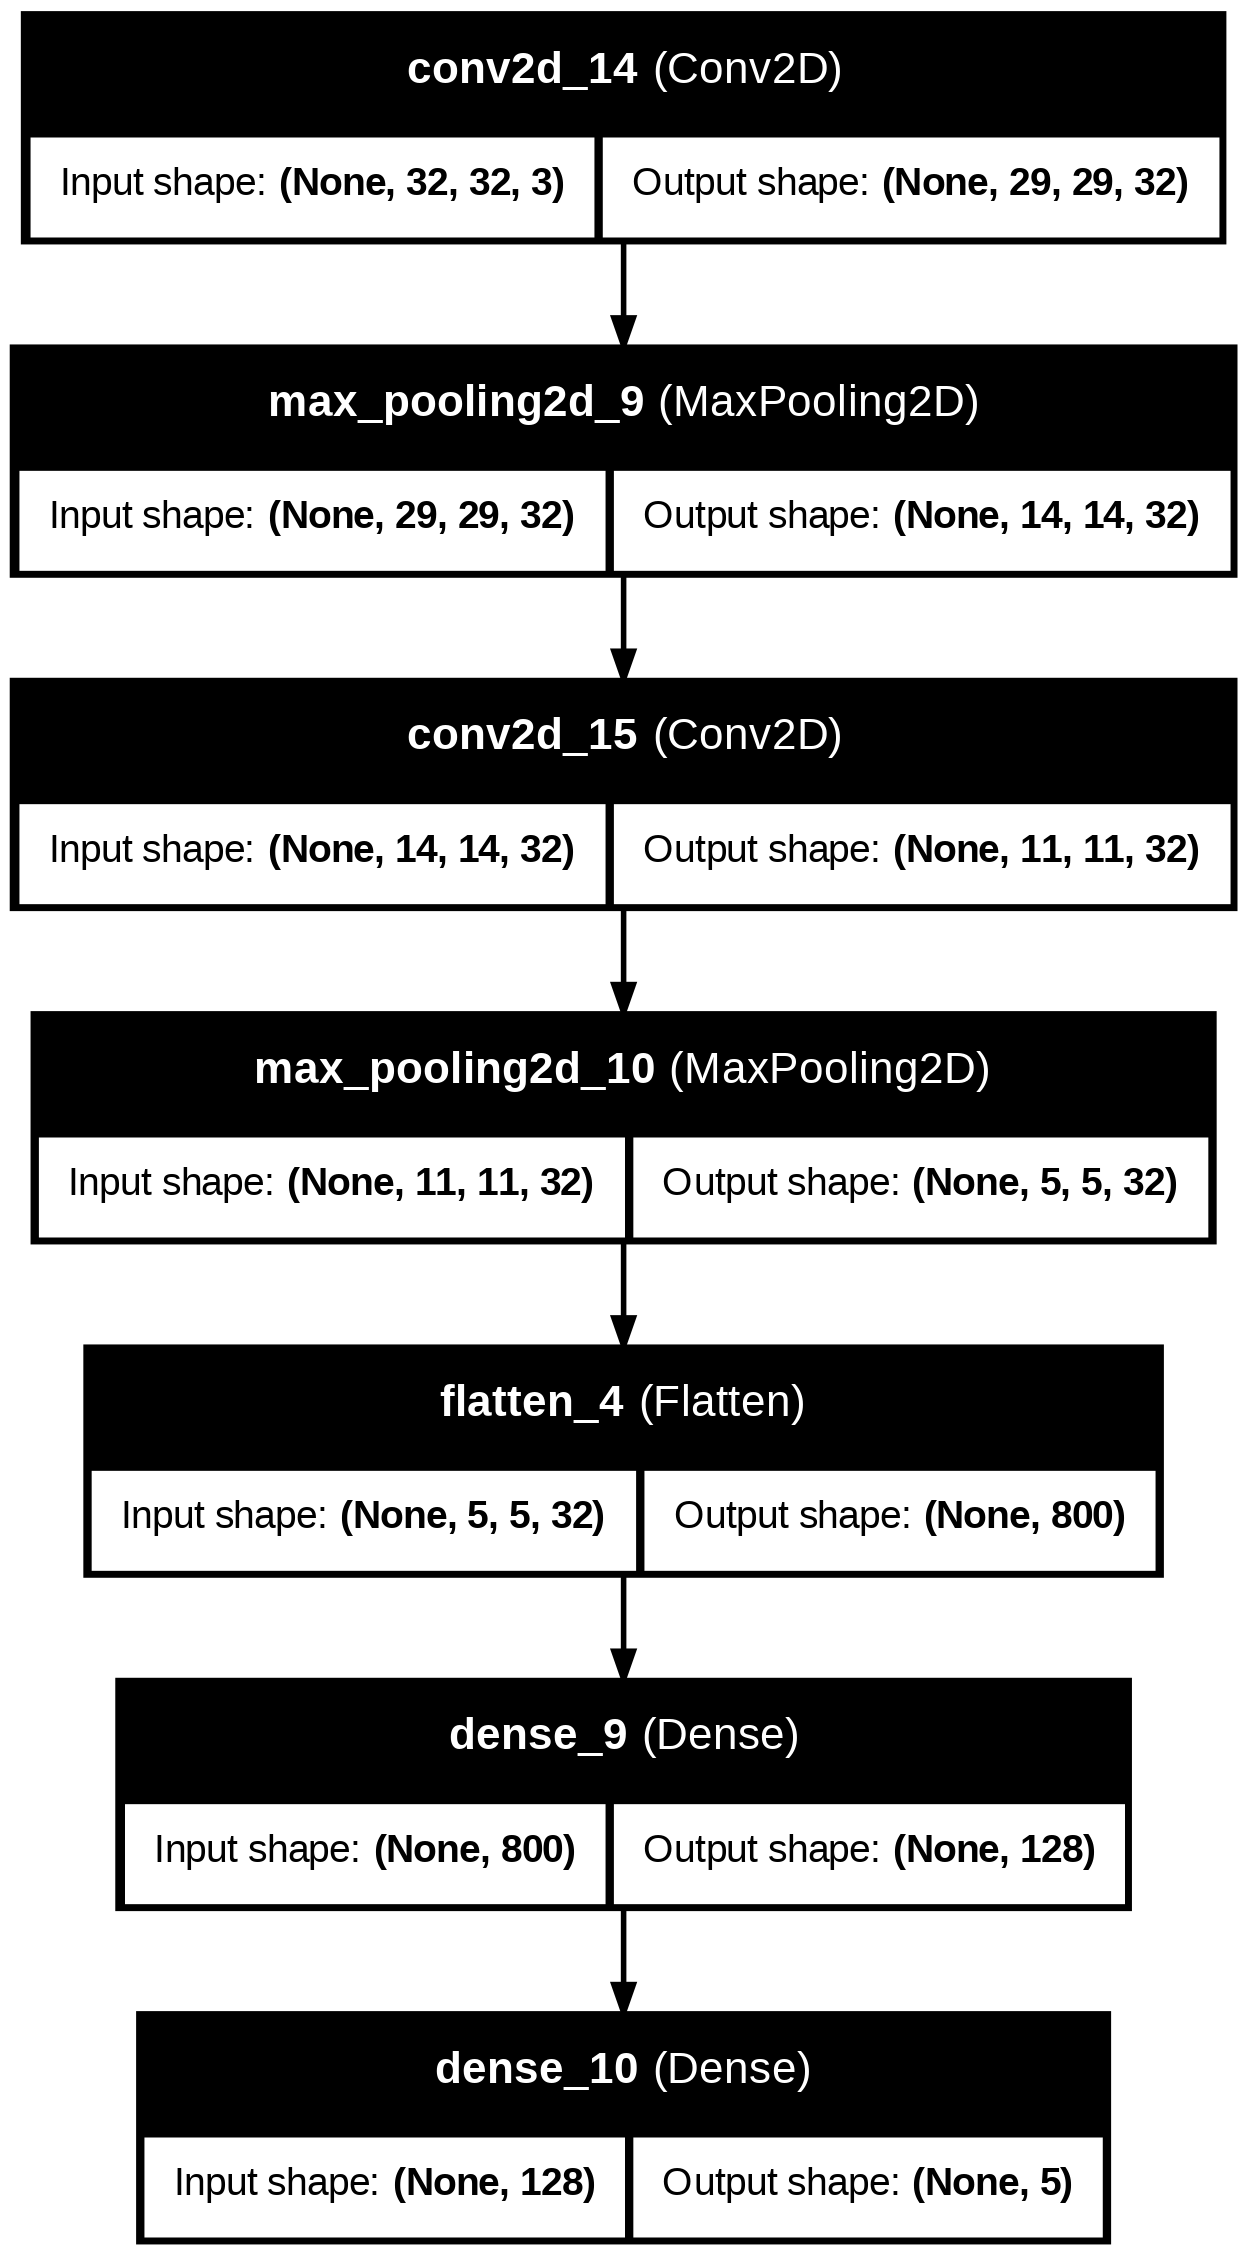

In [44]:
from tensorflow.keras.utils import plot_model
plot_model(model0, to_file='cnn_plot.png', show_shapes=True, show_layer_names=True)

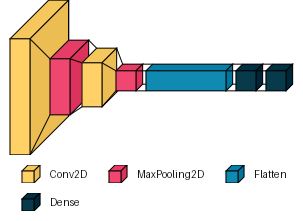

In [45]:
visualkeras.layered_view(model0, legend=True)

In [46]:
evaluation = model0.evaluate(X_test, Y_test_en)
print('Test Accuracy of Base Model: {}'.format(evaluation[1]))

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6994 - loss: 1.9008
Test Accuracy of Base Model: 0.7020000219345093


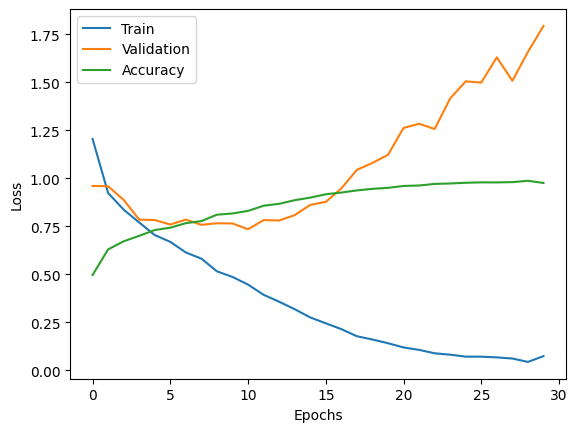

In [47]:
def plotloss(history):
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.plot(history.history['accuracy'])
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation', 'Accuracy'])
    plt.show()
plotloss(history)

 After running our base model with 30 Epochs, we are getting ~91% training accuracy and ~64% test accuracy which is good but as we can see the validation loss is continuously increasing from the first epoch till the last epoch i.e our base model is overfitting.
<br><br>
We can achieve this by adding a few dropout layers in our model. Now we are building our model by dropping 25% of units.

## Model 1 with Dropout

In [48]:
# Model_1 with Dropouts
model_1 = Sequential()
model_1.add(Conv2D(64,(4,4),input_shape=(32,32,3),activation='relu'))
model_1.add(MaxPooling2D(pool_size=(2,2)))
model_1.add(Dropout(0.5))
model_1.add(Conv2D(64,(4,4),input_shape=(32,32,3),activation='relu'))
model_1.add(MaxPooling2D(pool_size=(2,2)))
model_1.add(Dropout(0.25))
model_1.add(Flatten())
model_1.add(Dense(256,activation='relu'))
model_1.add(Dense(5,activation='softmax'))
model_1.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [49]:
model_1.summary()
history_1 = model_1.fit(X_train, Y_train_en, epochs = 50, verbose=1, validation_data=(X_test,Y_test_en))

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 29, 29, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 11, 11, 64)     │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 479,877 (1.83 MB)

 Trainable params: 479,877 (1.83 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.3996 - loss: 1.3597 - val_accuracy: 0.6372 - val_loss: 0.9568
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6226 - loss: 0.9327 - val_accuracy: 0.6380 - val_loss: 0.8996
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6500 - loss: 0.8758 - val_accuracy: 0.6884 - val_loss: 0.8265
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6920 - loss: 0.7981 - val_accuracy: 0.6988 - val_loss: 0.7788
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7136 - loss: 0.7223 - val_accuracy: 0.7248 - val_loss: 0.7270
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7527 - loss: 0.6691 - val_accuracy: 0.7308 - val_loss: 0.7133
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7615 - loss: 0.6294 - val_accuracy: 0.7232 - val_loss: 0.7348
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7717 - loss: 0.5869 - val_accuracy: 0

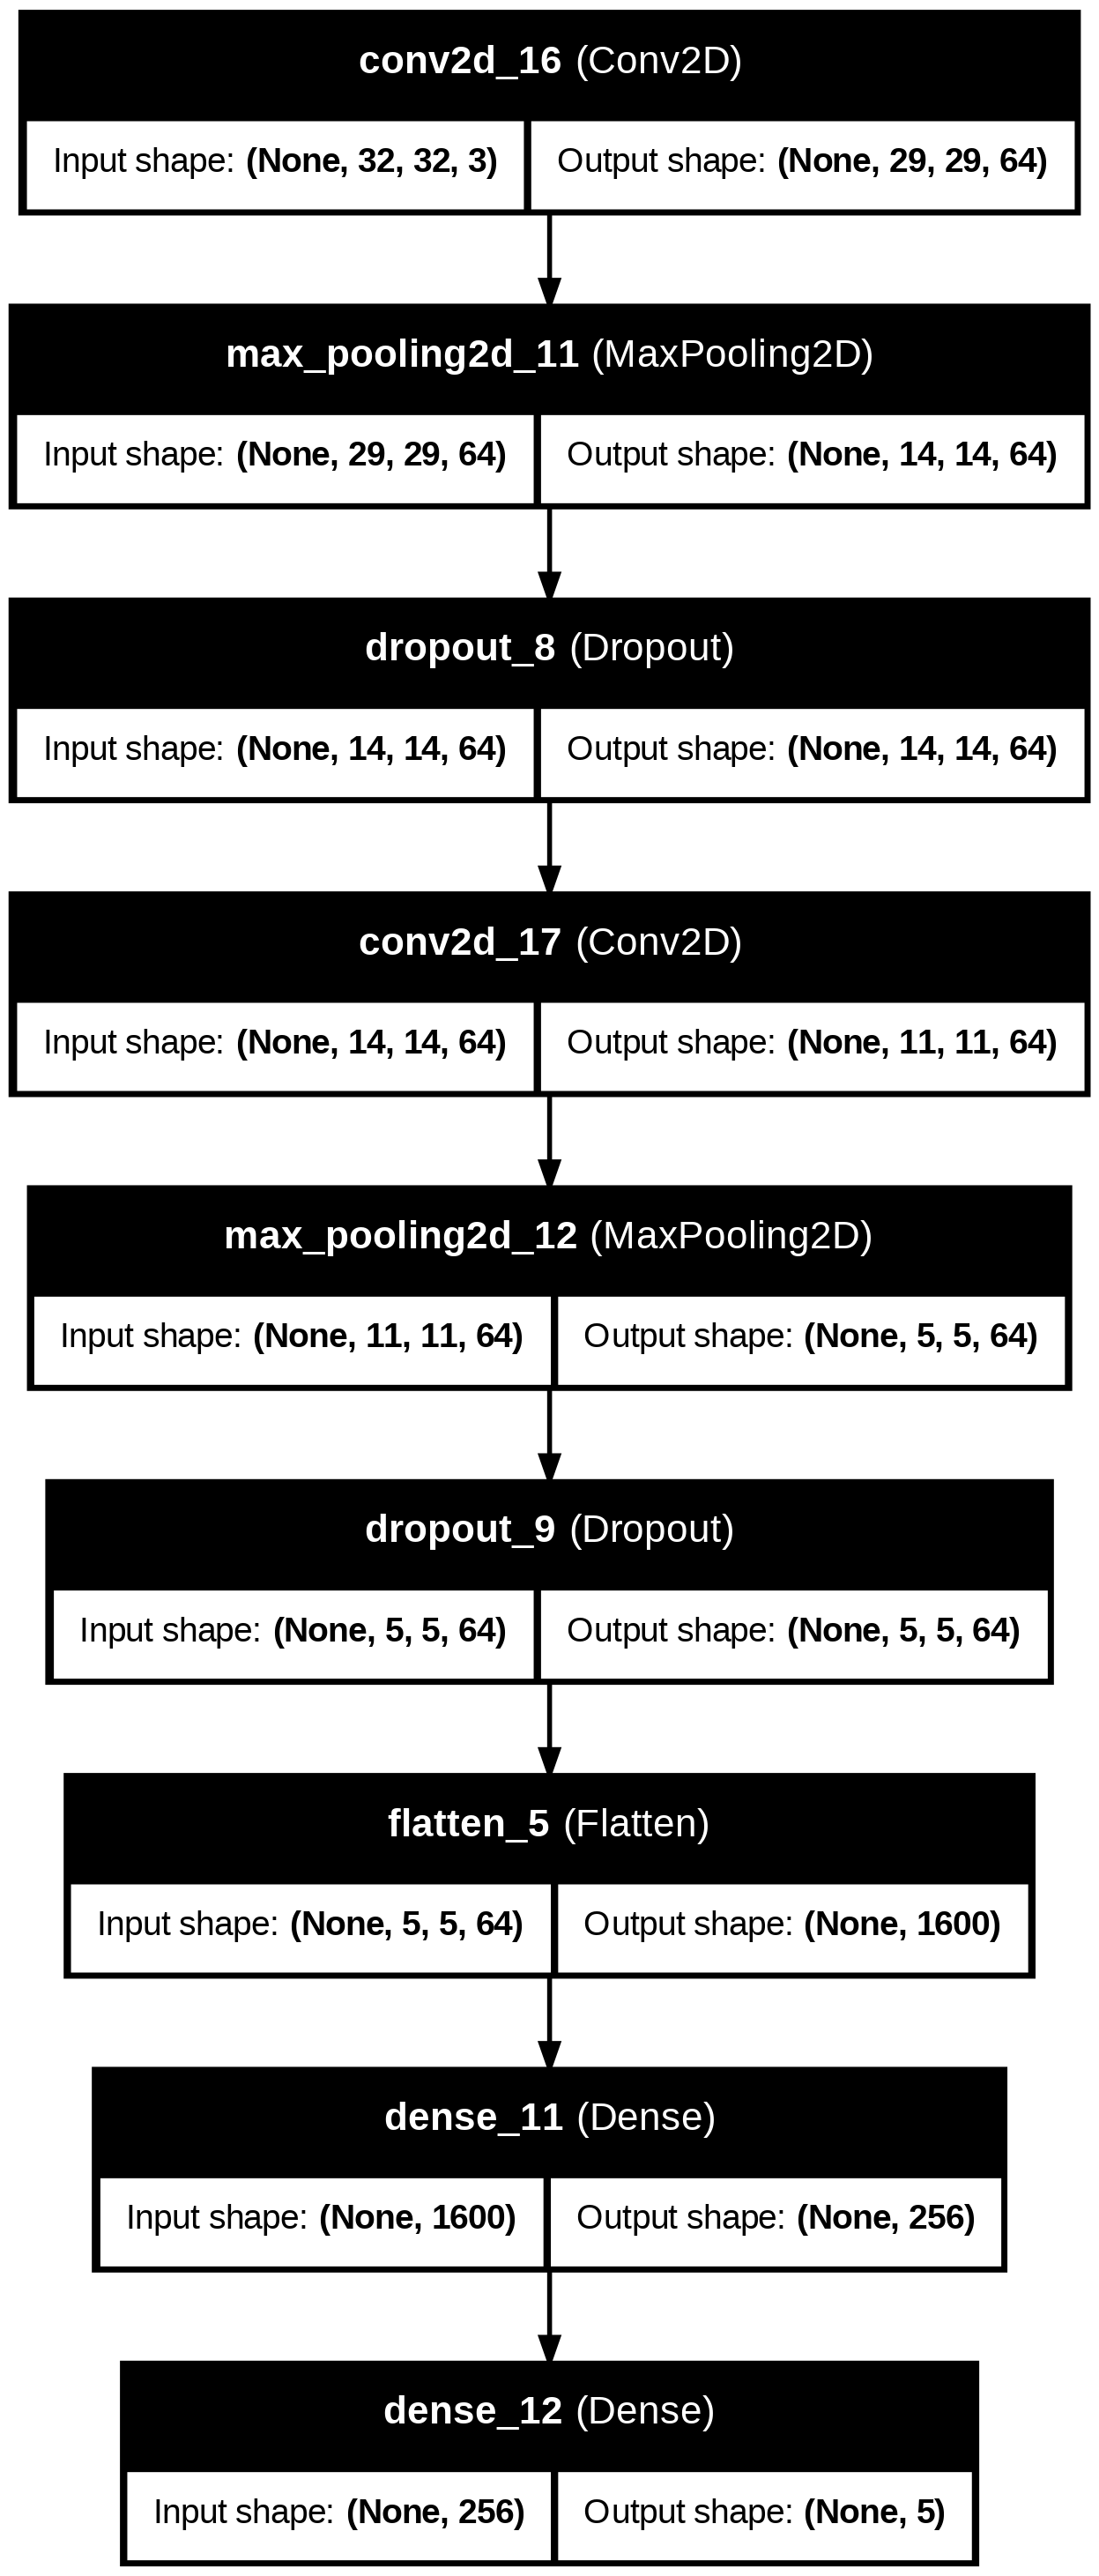

In [50]:
from tensorflow.keras.utils import plot_model
plot_model(model_1, to_file='cnn_plot.png', show_shapes=True, show_layer_names=True)

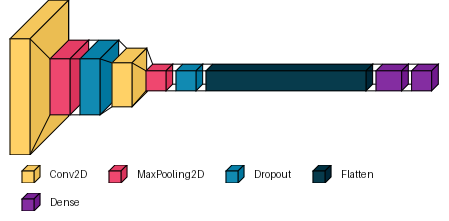

In [51]:
visualkeras.layered_view(model_1, legend=True)

In [52]:
evaluation = model_1.evaluate(X_test, Y_test_en)
print('Test Accuracy of Model_1(with Dropouts): {}'.format(evaluation[1]))

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7549 - loss: 1.4254
Test Accuracy of Model_1(with Dropouts): 0.758400022983551


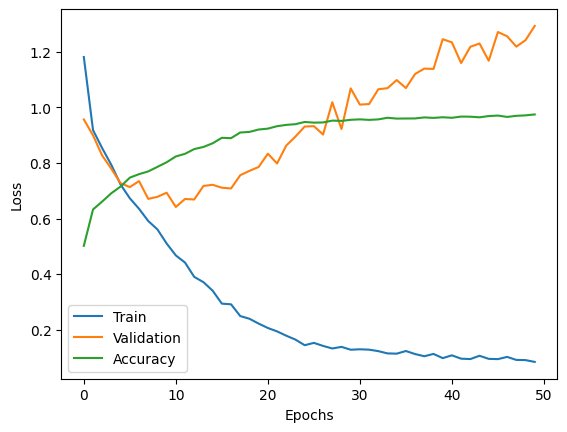

In [53]:
def plotloss(history_1):
    plt.plot(history_1.history['loss'])
    plt.plot(history_1.history['val_loss'])
    plt.plot(history_1.history['accuracy'])
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation', 'Accuracy'])
    plt.show()
plotloss(history_1)

 After running our model_1 with 50 Epochs, we can see that the validation accuracy has improved to 71% due to reduction in our model’s validation loss from 1.79 to 1.09.
<br><br>    
We will continue to train our model by increasing the number of epochs and by adding more filters.

## Model 2 with more Filters for better results

In [54]:
# Model_2 with more filters
model_2 = Sequential()
model_2.add(Conv2D(64,(4,4),input_shape=(32,32,3),activation='relu'))
model_2.add(Conv2D(64,(4,4),input_shape=(32,32,3),activation='relu'))
model_2.add(MaxPooling2D(pool_size=(2,2)))
model_2.add(Dropout(0.4))
model_2.add(Conv2D(128,(4,4),input_shape=(32,32,3),activation='relu'))
model_2.add(Conv2D(128,(4,4),input_shape=(32,32,3),activation='relu'))
model_2.add(MaxPooling2D(pool_size=(2,2)))
model_2.add(Dropout(0.4))
model_2.add(Flatten())
model_2.add(Dense(1024,activation='relu'))
model_2.add(Dense(1024,activation='relu'))
model_2.add(Dense(units =5  , activation = 'softmax'))
model_2.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [55]:
model_2.summary()
history_2 = model_2.fit(X_train, Y_train_en, epochs = 100, verbose=1, validation_data=(X_test,Y_test_en))

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 29, 29, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 26, 26, 64)     │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 10, 10, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 7, 7, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1024)           │     1,180,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │         5,125 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,697,605 (10.29 MB)

 Trainable params: 2,697,605 (10.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.3364 - loss: 1.4217 - val_accuracy: 0.5472 - val_loss: 1.0322
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5601 - loss: 1.0413 - val_accuracy: 0.6096 - val_loss: 0.9546
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6097 - loss: 0.9392 - val_accuracy: 0.6624 - val_loss: 0.8698
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6535 - loss: 0.8694 - val_accuracy: 0.6560 - val_loss: 0.9012
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6721 - loss: 0.8451 - val_accuracy: 0.6956 - val_loss: 0.7930
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6964 - loss: 0.7859 - val_accuracy: 0.7012 - val_loss: 0.8045
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7078 - loss: 0.7444 - val_accuracy: 0.7088 - val_loss: 0.7511
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7195 - loss: 0.7236 - val_ac

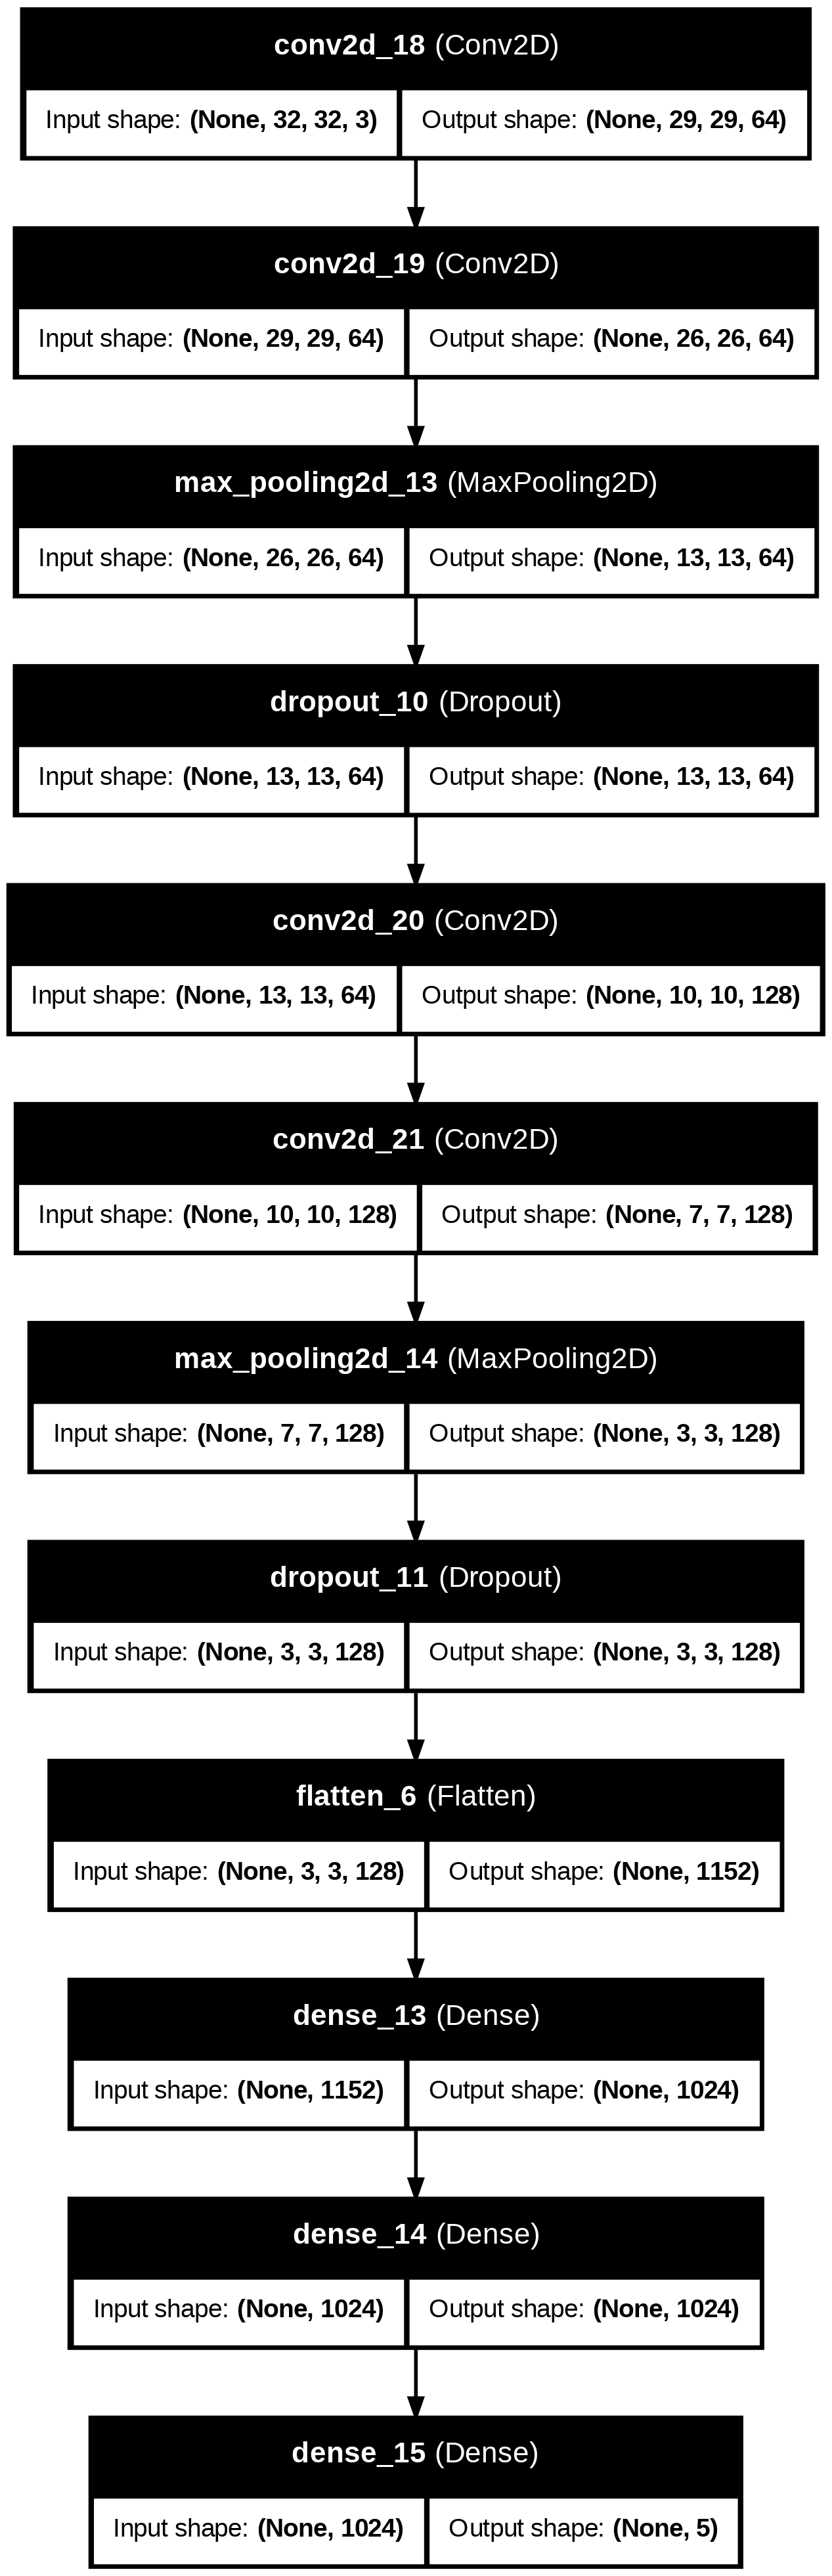

In [56]:
from tensorflow.keras.utils import plot_model
plot_model(model_2, to_file='cnn_plot.png', show_shapes=True, show_layer_names=True)

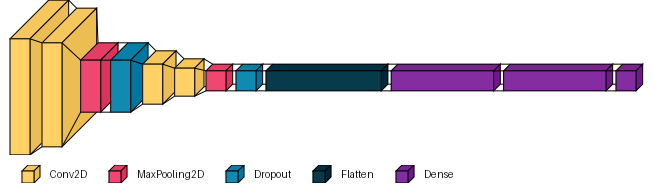

In [57]:
visualkeras.layered_view(model_2, legend=True)

In [58]:
evaluation = model_2.evaluate(X_test, Y_test_en)
print('Test Accuracy of Model_2(with more  filters): {}'.format(evaluation[1]))

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7697 - loss: 1.1262
Test Accuracy of Model_2(with more  filters): 0.7824000120162964


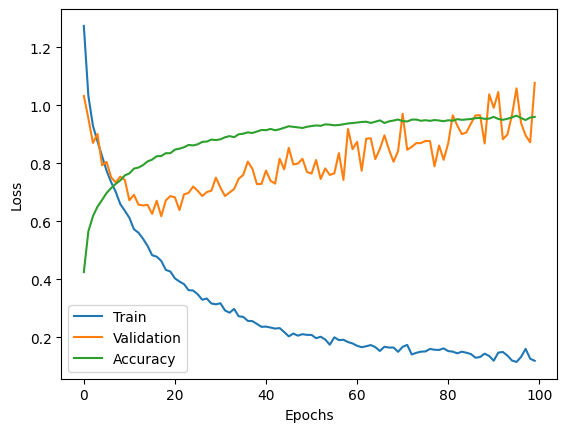

In [59]:
def plotloss(history_2):
    plt.plot(history_2.history['loss'])
    plt.plot(history_2.history['val_loss'])
    plt.plot(history_2.history['accuracy'])
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation', 'Accuracy'])
    plt.show()
plotloss(history_2)

 After running our model_2 with 100 Epochs, we can see that the validation accuracy has further improved to 74%
<br><br>
We will continue to train our model by adding Batch Normalization.



## Model-3 with Batch Normalization

In [60]:
# Model_3 with Batch Normalization
model_3 = Sequential()
model_3.add(Conv2D(64,(4,4),input_shape=(32,32,3),activation='relu',padding='same'))
model_3.add(BatchNormalization())
model_3.add(Conv2D(64,(4,4),input_shape=(32,32,3),activation='relu',padding='same'))
model_3.add(BatchNormalization())
model_3.add(MaxPooling2D(pool_size=(2,2)))
model_3.add(Dropout(0.2))
model_3.add(Conv2D(128,(4,4),input_shape=(32,32,3),activation='relu',padding='same'))
model_3.add(BatchNormalization())
model_3.add(Conv2D(128,(4,4),input_shape=(32,32,3),activation='relu',padding='same'))
model_3.add(BatchNormalization())
model_3.add(MaxPooling2D(pool_size=(2,2)))
model_3.add(Dropout(0.25))
model_3.add(Conv2D(128,(4,4),input_shape=(32,32,3),activation='relu',padding='same'))
model_3.add(BatchNormalization())
model_3.add(Conv2D(128,(4,4),input_shape=(32,32,3),activation='relu',padding='same'))
model_3.add(BatchNormalization())
model_3.add(MaxPooling2D(pool_size=(2,2)))
model_3.add(Dropout(0.35))
model_3.add(Flatten())
model_3.add(Dense(256, activation='relu'))
model_3.add(BatchNormalization())
model_3.add(Dropout(0.5))
model_3.add(Dense(5, activation='softmax'))
model_3.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [61]:
model_3.summary()
history_3 = model_3.fit(X_train, Y_train_en, epochs = 100, verbose = 1, validation_data = (X_test, Y_test_en))

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 64)     │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 64)     │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 16, 16, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 16, 16, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 8, 8, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 8, 8, 128)      │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,516,165 (5.78 MB)

 Trainable params: 1,514,373 (5.78 MB)

 Non-trainable params: 1,792 (7.00 KB)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.4354 - loss: 1.7248 - val_accuracy: 0.2928 - val_loss: 2.1326
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6185 - loss: 0.9786 - val_accuracy: 0.7068 - val_loss: 0.7934
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.6993 - loss: 0.7768 - val_accuracy: 0.6904 - val_loss: 0.8246
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7317 - loss: 0.6878 - val_accuracy: 0.7488 - val_loss: 0.6495
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7794 - loss: 0.5846 - val_accuracy: 0.6796 - val_loss: 0.8605
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8049 - loss: 0.5195 - val_accuracy: 0.5952 - val_loss: 1.0728
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8269 - loss: 0.4496 - val_accuracy: 0.7884 - val_loss: 0.6367
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8442 - loss: 0.4088 -

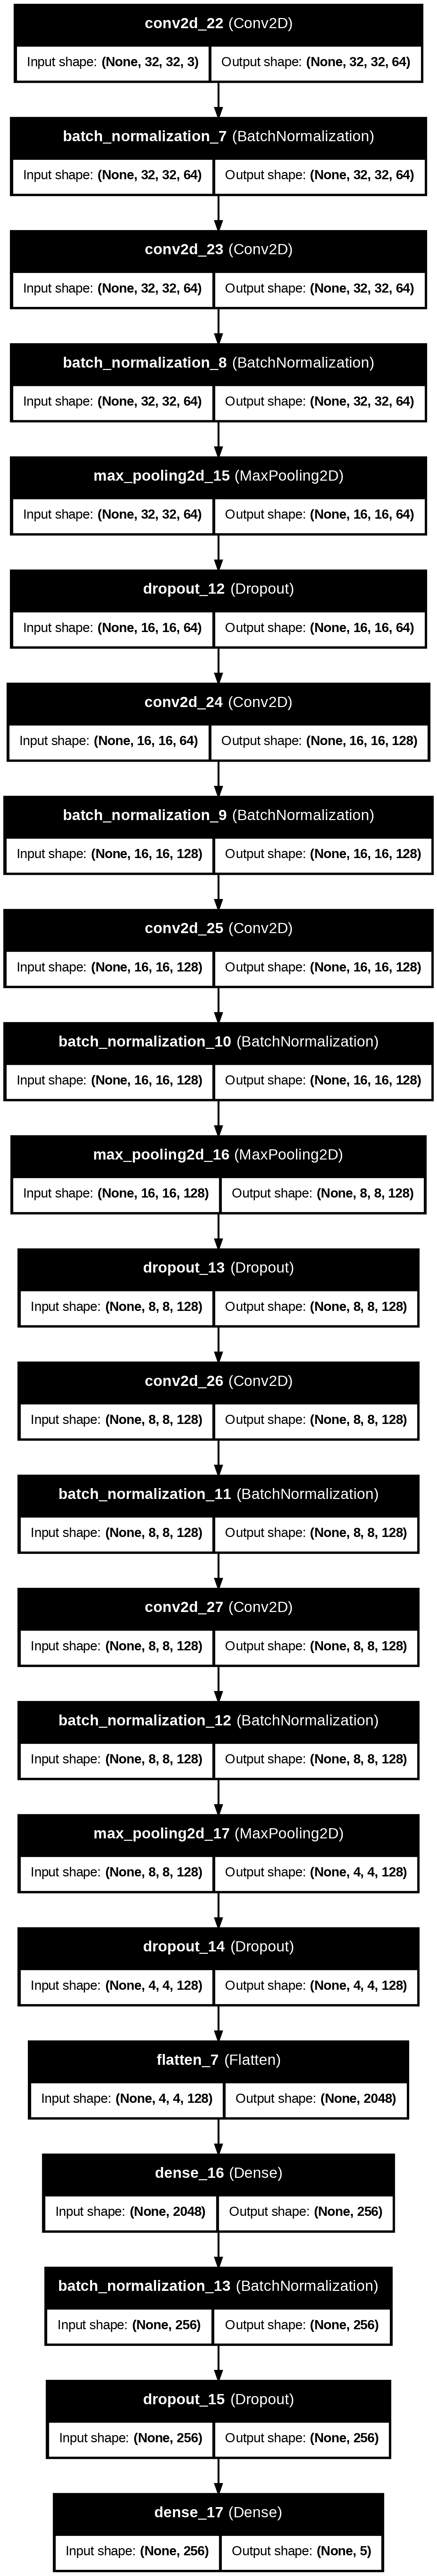

In [62]:
from tensorflow.keras.utils import plot_model
plot_model(model_3, to_file='cnn_plot.png', show_shapes=True, show_layer_names=True)

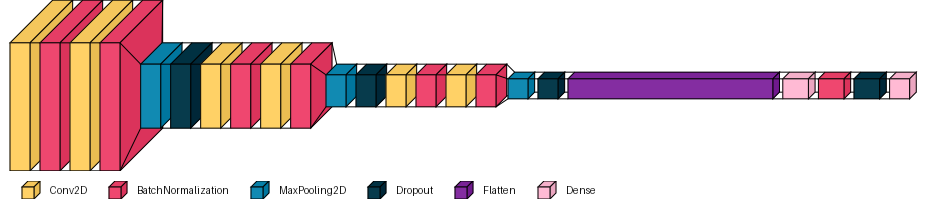

In [63]:
visualkeras.layered_view(model_3, legend=True)

In [64]:
evaluation = model_3.evaluate(X_test, Y_test_en)
print('Test Accuracy of Model_3 (with Batch Normalization): {}'.format(evaluation[1]))

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8654 - loss: 0.6947
Test Accuracy of Model_3 (with Batch Normalization): 0.8744000196456909


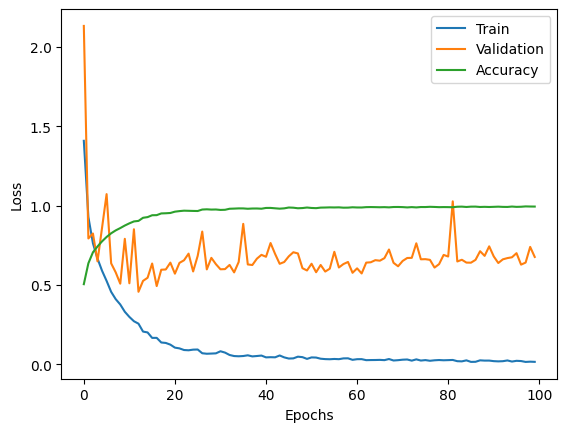

In [65]:
def plotloss(history_3):
    plt.plot(history_3.history['loss'])
    plt.plot(history_3.history['val_loss'])
    plt.plot(history_3.history['accuracy'])
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(['Train', 'Validation', 'Accuracy'])
    plt.show()
plotloss(history_3)

 After running our model_3 with Batch Normalization, we can see that the validation accuracy has further improved to 87%


## Using VGG16

What is VGG16?

* VGG16 is a deep CNN architecture with 16 weight layers (13 convolutional + 3 fully connected), known for using only small 3×3 filters and 2×2 max pooling layers in a very consistent and simple structure.

* It processes 224×224×3 input images, increasing filter depth progressively (64 → 512), while reducing spatial resolution through pooling, and ends with fully connected layers and a softmax classifier over 1000 classes.

* Trained on the large-scale ImageNet dataset, VGG16 achieved ~71% top-1 and ~89% top-5 accuracy, and it's widely used in practice for transfer learning due to its solid performance and generalizability.

* Compared to basic CNNs, VGG16 is much deeper, uses more filters per layer, and follows a strictly uniform design (all 3×3 convs), while basic CNNs often mix filter sizes and stay shallow.

* VGG16 has ~138 million parameters, making it heavier but also more expressive than a standard CNN; its pretrained version is often reused in various computer vision tasks for fine-tuning.

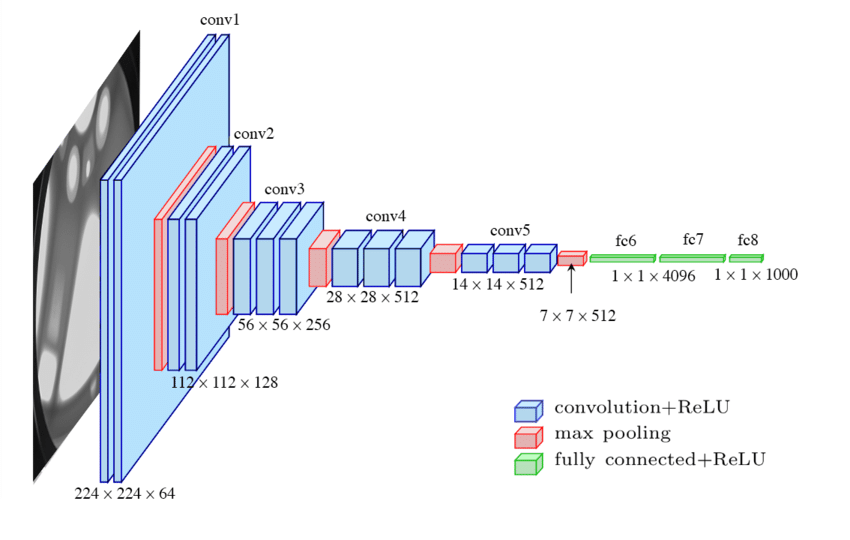

In [66]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
num_epochs = 5
batch_size = 40
learning_rate = 0.001
classes = ('plane', 'car' , 'bird','cat', 'ship')

cuda


In [67]:
transform = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
       (0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)
    )
])
train_dataset = torchvision.datasets.CIFAR10(
    root= './data', train = True,
    download =True, transform = transform)
test_dataset = torchvision.datasets.CIFAR10(
    root= './data', train = False,
    download =True, transform = transform)

100%|██████████| 170M/170M [00:02<00:00, 76.7MB/s] 


In [68]:
train_loader = torch.utils.data.DataLoader(train_dataset
    , batch_size = batch_size
    , shuffle = True)
test_loader = torch.utils.data.DataLoader(test_dataset
    , batch_size = batch_size
    , shuffle = True)
n_total_step = len(train_loader)
print(n_total_step)

1250


In [69]:
model = models.vgg16(pretrained = True)
input_lastLayer = model.classifier[6].in_features
model.classifier[6] = nn.Linear(input_lastLayer,10)
model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate, momentum=0.9,weight_decay=5e-4)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 218MB/s]  


In [70]:
for epoch in range(num_epochs):
    for i, (imgs , labels) in enumerate(train_loader):
        imgs = imgs.to(device)
        labels = labels.to(device)

        labels_hat = model(imgs)
        n_corrects = (labels_hat.argmax(axis=1)==labels).sum().item()
        loss_value = criterion(labels_hat, labels)
        loss_value.backward()
        optimizer.step()
        optimizer.zero_grad()
        if (i+1) % 250 == 0:
           print(f'epoch {epoch+1}/{num_epochs}, step: {i+1}/{n_total_step}: loss = {loss_value:.5f}, acc = {100*(n_corrects/labels.size(0)):.2f}%')
    print()

epoch 1/5, step: 250/1250: loss = 0.32098, acc = 90.00%
epoch 1/5, step: 500/1250: loss = 0.36379, acc = 90.00%
epoch 1/5, step: 750/1250: loss = 0.39894, acc = 85.00%
epoch 1/5, step: 1000/1250: loss = 0.25816, acc = 87.50%
epoch 1/5, step: 1250/1250: loss = 0.12216, acc = 95.00%

epoch 2/5, step: 250/1250: loss = 0.17906, acc = 95.00%
epoch 2/5, step: 500/1250: loss = 0.07074, acc = 97.50%
epoch 2/5, step: 750/1250: loss = 0.28985, acc = 95.00%
epoch 2/5, step: 1000/1250: loss = 0.19530, acc = 97.50%
epoch 2/5, step: 1250/1250: loss = 0.21955, acc = 95.00%

epoch 3/5, step: 250/1250: loss = 0.14940, acc = 95.00%
epoch 3/5, step: 500/1250: loss = 0.06300, acc = 97.50%
epoch 3/5, step: 750/1250: loss = 0.02145, acc = 100.00%
epoch 3/5, step: 1000/1250: loss = 0.17542, acc = 95.00%
epoch 3/5, step: 1250/1250: loss = 0.05922, acc = 100.00%

epoch 4/5, step: 250/1250: loss = 0.20258, acc = 97.50%
epoch 4/5, step: 500/1250: loss = 0.16635, acc = 97.50%
epoch 4/5, step: 750/1250: loss = 0.0

In [71]:
torch.save(model,"vggmodel")

In [72]:
with torch.no_grad():
    number_corrects = 0
    number_samples = 0
    for i, (test_images_set , test_labels_set) in enumerate(test_loader):
        test_images_set = test_images_set.to(device)
        test_labels_set = test_labels_set.to(device)

        y_predicted = model(test_images_set)
        labels_predicted = y_predicted.argmax(axis = 1)
        number_corrects += (labels_predicted==test_labels_set).sum().item()
        number_samples += test_labels_set.size(0)
    print(f"Overall accuracy {(number_corrects / number_samples)*100}%")

Overall accuracy 92.34%


We see that a pretrained VGG16 when trained further on CIFAR-10 dataset, performs very well. It is probably difficult for Quantum Networks to achieve such accuracy but it is vital to test whether quantum concepts can provide major advantages to image classification by using their properties like superpositioning and entanglement.


## Final Results

CNN (best model)- 88%
VGG16- 91% Accuracy

In [83]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# List your trained models and names here
models = [
    ('BaseModel',model0),
    ('Model_1', model_1),
    ('Model_2', model_2),
    ('Model_3',model_3),
    
    # Add more if needed
]

# DataLoader for test set
# Make sure you have this defined already
# test_loader = ...

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

results = []

for name, model in models:
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro')
    rec = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
    })

# Create DataFrame
df_results = pd.DataFrame(results)

# Display table
print(df_results)

# Save to CSV (optional)
df_results.to_csv('model_comparison_metrics.csv', index=False)

# Bar plot for comparison
df_results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', figsize=(10,6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


AttributeError: 'Sequential' object has no attribute 'to'

In [84]:
for name, model in models:
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro')
    rec = recall_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')

    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
    })

    # ✅ Save model
    torch.save(model.state_dict(), f"{name}_weights.pth")


AttributeError: 'Sequential' object has no attribute 'to'